In [1]:
import importlib 
m = importlib.import_module(".model_oop", "src")
from matplotlib import pyplot as plt
import numpy as np
import xgi

# Generate a synthetic hypergraph

In [24]:
# generate some sample data

eta   = 0.7   # node retention in edges
gamma = 0.5   # poisson number of nodes from graph
beta  = 0.5   # poisson number of novel nodes

timesteps = int(1e2)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)

In [25]:
H.H_vecs[-1].num_edges

101

## First Experiment

To see if this works well, let's try learning the parameters for a bunch of hypergraphs all with the same true parameters, and seeing whether we are able to get close. 

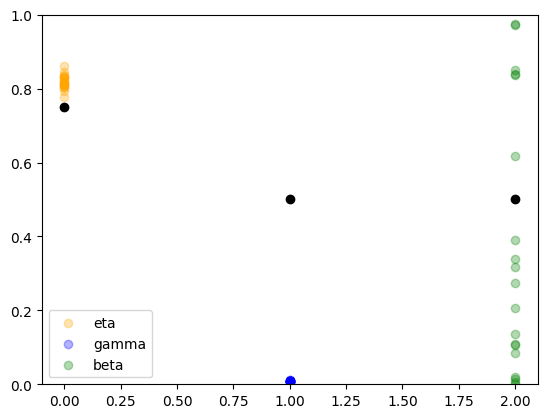

In [36]:
timesteps = int(2e2)

heta, hgamma, hbeta = 0.75, 0.5, 0.5
para = heta, hgamma, hbeta

em = importlib.import_module(".em", "src")
for i in range(20):
    H = m.GrowingHypergraph()
    H.add_edge((0, 1))
    H.add_edge((2, 3))

    for _ in range(timesteps):
        H.sample_edge(heta, hgamma, hbeta, True)

    model = em.EM(mode = "guaranteed") # to be implemented
    model.fit(H)
    model.par()
    model.loss()        # value of the log-likelihood with observed parameters
    
    colors = ["orange", "blue", "green"]
    if i >= 1:
        labs = [None, None, None]
    else:
        labs = ["eta", "gamma", "beta"]
        
    for j in range(3):
        plt.scatter([j], [model.par()[j]], label = labs[j], color = colors[j], alpha = 0.3)
    
plt.scatter([0], [heta],   color = "black")
plt.scatter([1], [hgamma], color = "black")
plt.scatter([2], [hbeta],  color = "black")

plt.gca().set(ylim = (0, 1))
plt.legend()

So it looks like: 

1. We are in the right general area for $\eta$ but we are consistently overetimating. 
2. We are consistently underestimating $\gamma$. 
3. We are observing a pretty wild range of estimates for $\beta$, some of which are overestimates and some of which are underestimates. 

# Implementation Tip: Even More Array-Focused

I haven't been able to operate the current implementation, but I do see some places in which we might be able to enhance speed and simply code or cut out some for-loops. Here's how to form a few arrays that I am pretty sure should help: 

*Note*: computing the intersection matrix below is likely to be slow for larger hypergraphs. 

In [9]:
IX = xgi.intersection_profile(H.H).toarray()
IX = np.triu(IX)
np.fill_diagonal(IX, 0) 
IX
# entry [i,j] of IX is the size of intersection of edge e_i with edge e_j, 
# but only if j > i (since then it is possible that edge i generated edge j)

array([[0, 0, 0, ..., 0, 2, 1],
       [0, 0, 2, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

In [4]:
novel_node_vec = []
seen = set()
for e in H.H.edges.members():
    novel_node_vec.append(len(e.difference(seen)))
    seen = seen.union(e)
    
novel_node_vec = np.array(novel_node_vec)

# entry i of novel_node_vec is the number of novel nodes that form edge i (not present in hypergraph before)

# I thought this could be done without a for-loop but I got stuck =(
    
novel_node_vec

array([2, 2, 0, ..., 1, 1, 0])

In [10]:
edge_size_vec = H.edge_size_sequence()
edge_size_vec

# entry i of edge_size_vec is the number of nodes in each edge

array([2, 2, 2, 2, 2, 3, 2, 3, 5, 4, 4, 3, 2, 3, 3, 3, 2, 2, 4, 2, 2, 2,
       1, 3, 6, 2, 1, 1, 2, 1, 2, 2, 1, 2, 3, 2, 3, 2, 1, 3, 4, 2, 3, 3,
       2, 3, 4, 1, 2, 3, 1, 1, 2, 4, 4, 4, 3, 4, 4, 4, 2, 2, 2, 5, 6, 3,
       3, 2, 3, 3, 2, 1, 5, 3, 3, 1, 6, 4, 5, 3, 4, 2, 4, 3, 3, 3, 2, 2,
       2, 3, 3, 3, 3, 3, 2, 5, 4, 2, 2, 4, 2, 1])

In [6]:
other_nodes_mat = (edge_size_vec - novel_node_vec) - IX
other_nodes_mat = np.triu(other_nodes_mat)
np.fill_diagonal(other_nodes_mat, 0) 
other_nodes_mat

# entry [i,j] of other_nodes_mat is the number of nodes that would have to come from the rest of the hypergraph if edge j was formed from edge i

# I am not 100% sure of the broadcasting here so checking is needed. 

array([[0, 0, 2, ..., 3, 3, 5],
       [0, 0, 0, ..., 3, 3, 5],
       [0, 0, 0, ..., 3, 3, 5],
       ...,
       [0, 0, 0, ..., 0, 3, 5],
       [0, 0, 0, ..., 0, 0, 5],
       [0, 0, 0, ..., 0, 0, 0]])

## Challenges

1. Can we form the matrix of $\chi$'s in the E-step without any more for-loops, using only vectorized numpy operations? 
2. Can we do the M-step using simple matrix multiplication and things like `array.sum(axis = 1)`, rather than relying on the challenging `einsum` notation?